# **Atividade Prática**
<font size=3>

- **Tema:** Problema de busca.
- **Prazo de entrega:** 15 de Setembro.
- **Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLScA7h6KaHZeqIW17Nek49r3F4MqX2VlN3rfgotORpe3epuHiw/viewform?usp=publish-editor).
---

## **Enunciado:**
<font size=3>
    
Baseado no **_notebook_ 3.2** ("Exemplo de Busca em Largura"), desenvolva duas soluções para encontrar uma rota em um mapa: uma com um algoritmo de **busca desinformada** e outra com um de **busca informada**.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive/')

---

### **1. Questão — Busca Desinformada:**
#### **1.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca desinformada** (que não seja *Busca em Largura*);

- Defina as coordenadas de origem e destino (*no Google Maps, ao clinar em uma posição no mapa com o botão direito, as coordenadas aparecem em um aba*);

- Defina o modo de percurso ("*drive*", "*walk*", "*bike*" ou "*all*");

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [ ]:
%pip install osmnx
%pip install matplotlib
%pip install scikit-learn

In [2]:
import osmnx as ox
import numpy as np
import heapq
import matplotlib.pyplot as plt
from networkx import MultiDiGraph
from collections import deque

In [3]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [4]:
class Problem1:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node1:

    def __init__(self, problem, parent = None, action = None, state = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node1) and self.state == other.state


    def __hash__(self):

        return hash(self.state)


In [5]:
class BidirectionalSearch:

    """
    Duas BFS simultâneas (start e goal). Ao encontrar um estado comum, 'costura' as metades
    e retorna um Node meta cuja cadeia de 'parent' reconstrói start -> ... -> goal (como no BFS).
    """

    def __init__(self, problem, goal_state):

        self.problem = problem
        self.goal_state = goal_state

        self.frontier_start = deque()
        self.explored_start = {}
        self.frontier_goal = deque()
        self.explored_goal = {}


    def search(self):

        root_start = Node1(self.problem, state = self.problem.initial_state)
        root_goal = Node1(self.problem, state = self.goal_state)

        if root_start.state == root_goal.state:
            return [root_start.state]

        self.frontier_start.append(root_start)
        self.explored_start[root_start.state] = root_start
        self.frontier_goal.append(root_goal)
        self.explored_goal[root_goal.state] = root_goal

        while self.frontier_start and self.frontier_goal:

            # expande a fronteira menor para otimizar o encontro:
            if len(self.frontier_start) <= len(self.frontier_goal):
                meet_node = self._expand_one_step(is_forward = True)
            else:
                meet_node = self._expand_one_step(is_forward = False)

            if meet_node:
                return self._reconstruct_path(meet_node['start'], meet_node['goal'])

        return None


    def _expand_one_step(self, is_forward):

        if is_forward:
            frontier, explored, other_explored = self.frontier_start, self.explored_start, self.explored_goal
        else:
            frontier, explored, other_explored = self.frontier_goal, self.explored_goal, self.explored_start

        if not frontier:
            return None

        node = frontier.popleft()

        # expande nó:
        for action in self.problem.actions(node.state, is_forward = is_forward):
            child = Node1(self.problem, node, action)

            if child.state not in explored:
                if child.state in other_explored:
                    if is_forward:
                        return {'start':child, 'goal':other_explored[child.state]}
                    else:
                        return {'start':other_explored[child.state], 'goal':child}

                frontier.append(child)
                explored[child.state] = child

        return None


    def _reconstruct_path(self, node_start, node_goal):

        path = []
        node = node_start

        while node:
            path.append(node.state)
            node = node.parent

        path.reverse()

        node = node_goal.parent

        while node:
            path.append(node.state)
            node = node.parent

        return path


In [6]:
class MapProblem(Problem1):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G: MultiDiGraph, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state, is_forward = True):
        if is_forward:
            return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)
        else:
            return self.G.predecessors(state) if hasattr(self.G, "predecessors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost = False):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            if not edge:
                edge = self.G.get_edge_data(action, state)
            return edge[0]['length']

In [7]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "drive"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 505103991


In [8]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

# definindo o modelo de busca:
bds = BidirectionalSearch(problem, goal)

# inicializando a busca:
path_nodes = bds.search()

In [9]:
# imprimindo o nome das ruas da rota:
print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

# Nós no caminho (UCS): 149  |  # arestas: 148
Ruas percorridas (aproximadamente):

01. Rua Renato Leitão de Almeida
02. Rua Brasil
03. Rua Sergipe
04. Rua 7
05. Rua 22
06. Rua 22
07. Rua 22
08. Rua 22
09. Rua Engenheiro Roberto Bezerra Freire
10. (sem nome)
11. (sem nome)
12. (sem nome)
13. (sem nome)
14. (sem nome)
15. (sem nome)
16. (sem nome)
17. (sem nome)
18. (sem nome)
19. Avenida Firmino Moura
20. Rua Pedro Miranda da Silva
21. Rua Pedro Miranda da Silva
22. Rua Pedro Miranda da Silva
23. Rua Pedro Miranda da Silva
24. Rua Vereador Aldo Mendes da Silva
25. Rua Olinto José Rodrigues
26. (sem nome)
27. Rua Alexandre Cavalcante
28. Rua Pedro de Alcantara Cavalcanti
29. Rua Pedro de Alcantara Cavalcanti
30. Rua Vereador Eri Teixeira Dantas
31. Rua Manoel Ferreira Gomes
32. Rua Manoel Ferreira Gomes
33. Rua Gonçalo Pinheiro
34. Rua Gonçalo Pinheiro
35. Rua Geraldo Cassemiro
36. Rua Geraldo Cassemiro
37. Rua Geraldo Cassemiro
38. Rua José Horácio de Góis
39. Rua José Horácio de Góis


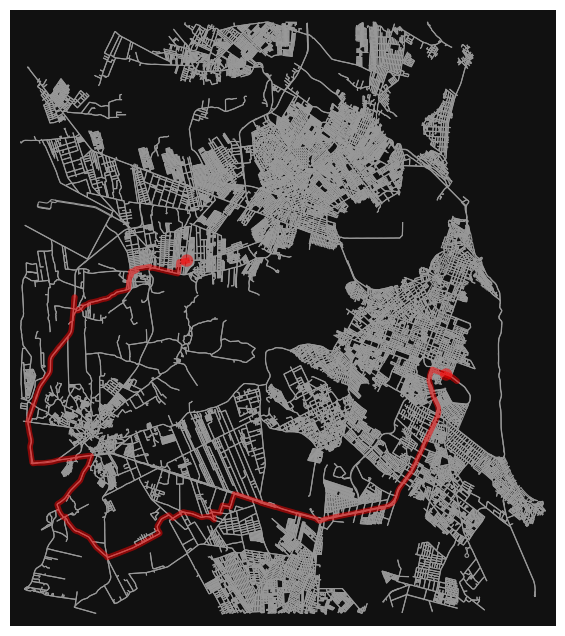

In [10]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()


### DiGraph Problem
Durante o exame das rotas geradas, foi observado que houve um problema em que um dos vizinhos não estava sendo encontrado. Isso levou a variável `path_nodes` a ficar sem a informação necessária para poder gerar o caminho corretamente, pois se tinha a ação e o estado, mas não havia o caminho (edge) entre eles.

Isso ocorreu porque no `MapProblem` disponibilizado via notebook 3.2 - [exemplo de busca em largura](https://colab.research.google.com/drive/1D3434-OnhrBQ3q-cSW0Sksle-BvDhTHP#scrollTo=f38b17de-f77a-42e8-8a66-f52812152478), o custo do caminho estava sendo dado da seguinte forma:

```py
def step_cost_fn(self, state, action, uniform_cost = True):

    if uniform_cost:
        return 1.0  # cada aresta custa 1 (custo uniforme).

    else:
        edge = self.G.get_edge_data(state, action)
        return edge[0]['length'] # comprimento da aresta/rua.
```

Salienta-se ainda que também houve um detalhe que quase passou despercebido, sendo em relação ao parâmetro `uniform_cost`, pois estava setado como `True`, ou seja, estava sendo considerado o custo uniforme. Entretanto, após colocar como `False`, a aresta (`edge`) passou a não ser encontrada, de modo que foi lançado um erro em uma das chamadas.

Diante disso, foi utilizada a ferramenta de debug da IDE - VS Code para investigar onde e quando estava ocorrendo o problema. Com isso, foi possível identificar que na terceira iteração ocorria o registro de um caminho que possuía apenas uma direção. Dessa forma, ao gerar os vizinhos do nó avaliado, um de seus vizinhos não estava sendo levado em consideração, pois nessa configuração que pode ser vista no `else` do trecho de código acima, não é levada em consideração a possibilidade de uma só direção (voltando), ou seja, quando um caminho tem apenas o sentido de volta, ele é desconsiderado, ou seja, tinha o registro da ação e do estado, mas não havia a ligação (edge) entre eles no sentido de estado -> ação, pois não era considerado vizinho.

Para resolver esse problema, foi realizada uma pequena modificação nesse trecho do `else` permitindo que um caminho que considera um único sentido, relacionado com o nó que está sendo avaliado, seja registrado como vizinho daquele nó. Desse modo, foi possível associar as ações e estados corretamente, permitindo gerar o grafo.

```py
 def step_cost_fn(self, state, action, uniform_cost = False):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action) # Leva em consideração apenas o sentido que parte do nó em questão para um outro nó (->) "seta indo".
            if not edge:
                edge = self.G.get_edge_data(action, state) # Leva em consideração o sentido que sai de algum outro nó e chega no nó em questão (<-) "seta voltando".
            return edge[0]['length']
```

* **Curiosidade**

Ao remover a direção do grafo utilizando a função `to_undirected`, o caminho gerado é um caminho mais curto, como se pode observar nas células a seguir:

*A hipótese de que isso ocorre é porque, talvez, ao remover a direção do grafo seja possível percorrê-lo com mais facilidade, pois as ruas que têm apenas um sentido passam a ter os dois (vira mão dupla). Entretanto, acredita-se que pode ocorrer de ser um caminho impossível de ser percorrido na prática.*

In [11]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "drive"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600).to_undirected()

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 505103991


In [12]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

# definindo o modelo de busca:
bds = BidirectionalSearch(problem, goal)

# inicializando a busca:
path_nodes = bds.search()

In [13]:
# imprimindo o nome das ruas da rota:
print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

# Nós no caminho (UCS): 125  |  # arestas: 124
Ruas percorridas (aproximadamente):

01. Rua Odilon Borges da Silva
02. Rua Corisco
03. Rua Corisco
04. Avenida Campos de Bagatelle
05. Rua Emanoel Hermógenes de Medeiros
06. Rua Major Nelson Varela Barca
07. Rua Major Nelson Varela Barca
08. Rua Major Nelson Varela Barca
09. Rua Major Nelson Varela Barca
10. Rua Vice-Presidente José Alencar Gomes da Silva
11. Rua Vice-Presidente José Alencar Gomes da Silva
12. Avenida João Dino Maia
13. Avenida João Dino Maia
14. Avenida João Dino Maia
15. Avenida João Dino Maia
16. Avenida João Dino Maia
17. Avenida João Dino Maia
18. Avenida João Dino Maia
19. Avenida João Dino Maia
20. Avenida João Dino Maia
21. Avenida João Dino Maia
22. Avenida João Dino Maia
23. Avenida João Dino Maia
24. Avenida João Dino Maia
25. Avenida Doutor Ruy Pereira dos Santos
26. Avenida Doutor Ruy Pereira dos Santos
27. Avenida Doutor Ruy Pereira dos Santos
28. Avenida Doutor Ruy Pereira dos Santos
29. Avenida Doutor Ruy 

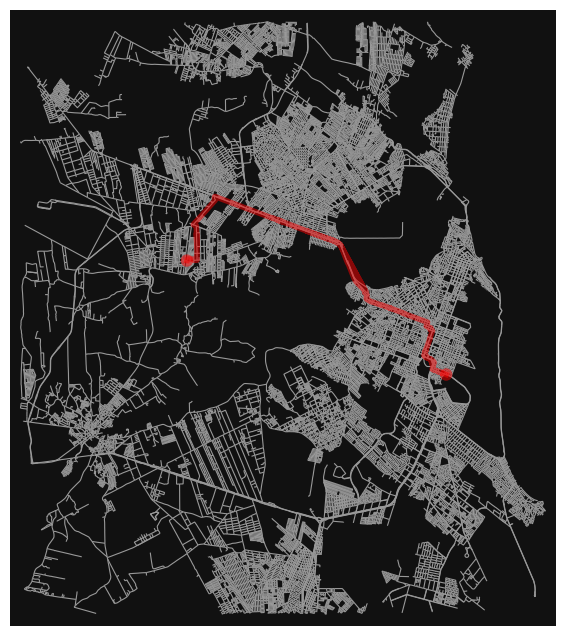

In [14]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()


#### **1.2 Análise:**
<font size=3>
    
Em uma **célula de markdown** compare o algoritmo que você escolheu com a **Busca em Largura (BFS)**, analisando os seguintes critérios:

- **Estrutura da Fronteira:** Qual estrutura de dados a fronteira utiliza (ex: Fila FIFO, Pilha LIFO, Fila de Prioridades)?

- **Otimalidade:** O seu algoritmo **garante** que a rota encontrada é a mais curta (com o menor número de ruas)? Justifique.

- **Complexidade:** Em geral, qual dos dois algoritmos (o seu ou o BFS) você espera que use mais memória para este problema de mapa? Por quê?
  

### Busca Bidirecional (Bidirectional Search) x Busca em Largura (Breadth Fist Search) 

* **Estrutura da Fronteira**
    * **Busca Bidirecional - Bidirectional Search** \
    A busca desinformada escolhida para a questão 1 foi a Busca Bidirecional e, com base no notebook 3 - [*resolução de problemas por meio de busca*](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D#scrollTo=017c6b82-c3af-46ff-972a-20d570696eca) seção 4.6, ela utiliza a estrutura de dados `deque` para abstrair o uso de duas filas do tipo `FIFO (First in, first out)`, sendo característica da Busca em Largura, ou seja, se tem *duas* Buscas em Largura, neste caso alternando, nesse tipo de busca: uma que parte da origem e outra que parte do destino. 
    
        Diante disso, as funções utilizadas para manipular/administrar essas filas foram: `append()` e `popleft()`, das quais estão definidas dentro da estrutura `deque`. Com isso, para melhor detalhar onde estão sendo utilizadas, segue abaixo o trecho do código indicando exatamente onde essas funções são chamadas:

    ````py
        class BidirectionalSearch:

        def __init__(self, problem, goal_state):

            (...)

            self.frontier_start = deque() #Cria a primeira fila vazia.
            self.frontier_goal = deque() #Cria a segunda fila vazia.

            (...)

        def search(self):

        (...)

        self.frontier_start.append(root_start) #Utiliza a função append() para inserir no final da fila, sendo, à priori, o primeiro item (nó) da primeira fila.
        self.explored_start[root_start.state] = root_start
        self.frontier_goal.append(root_goal) #Utiliza a função append() para inserir no final da fila, sendo, inicialmente, o primeiro nó da segunda fila.
        self.explored_goal[root_goal.state] = root_goal

        (...)

        def _expand_one_step(self, is_forward):

            (...)

            node = frontier.popleft() #Usa a função popleft() para remover o primeiro item da fila.

            # expande nó:
            for action in self.problem.actions(node.state, is_forward = is_forward):
                (...)

                    frontier.append(child) #Insere os nós filhos na fronteira (final da fila) a serem explorados depois.

                (...)
        
    ````
    * **Busca em Largura - BFS** \
    De acordo com o material disponibilizado no notebook 3 - [*resolução de problemas por meio de busca*](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D#scrollTo=017c6b82-c3af-46ff-972a-20d570696eca) na seção *4.1*, a Busca em Largura usa apenas *uma* `FIFO` na implementação do algoritmo, de modo que serão explorados todos os nós da fronteira e, somente após essa varredura, passa então para o nível inferior e explora os nós dessa próxima fronteira.

    * **Distinção** \
    A principal diferença que se pode notar entre esses dois tipos de busca, levando em consideração que é uma comparação acerca da *estrutura da fronteira*, é que em uma busca se utiliza *duas* filas do tipo `FIFO`, sendo a *Bidirecional*, enquanto que a outra (*Busca em Largura*) usa apenas *uma* fila do tipo `FIFO`.

* **Otimalidade** \
Assim como a *BFS*, a *Busca Bidirecional* não é otimizada para encontrar o melhor percurso, já que é uma busca à base da Busca em Largura (BFS) e, mais especificamente, é uma busca cega. Nesse sentido, em sua estrutura padrão será possível encontrar uma solução, porém esta será apenas a primeira a ser encontrada, não sendo garantido que seja retornada a melhor solução, pois como se trata do uso de *duas* Buscas em Largura, utilizando duas `FIFOs`, ambas estarão explorando toda a fronteira a cada nível e, assim que os nós em ambas as filas coincidem, então o caminho é formado entre a origem e o destino, encerrando a busca, ou seja, impossibilitando encontrar uma melhor solução, que poderia estar em um nó posterior àquele que coincidiu primeiro. 

    Todavia, a depender dos pontos de origem e de destino, é possível que o caminho formado seja a solução ótima. Nesse caso, quanto menos vizinhos existirem entre os pontos de origem e de destino, provavelmente as chances de ser retornado a solução ótima aumentam, pois por ser uma busca as cegas o custo do caminho não é levado em consideração e, portanto, o caminho se forma a partir da quantidade de nós vizinhos do nó que está sendo explorado.

* **Complexidade** \
Levando em consideração que a Busca Bidirecional utiliza duas `FIFOs`, em um primeiro momento podemos achar que utiliza mais recurso de memória. Todavia, tomando como base o [material](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D#scrollTo=017c6b82-c3af-46ff-972a-20d570696eca) disponibilizado pelo Prof. Dr. Tibério Pereira, na seção 4.6, podemos ver que a complexidade de espaço é de aproximadamente O(b<sup>d/2</sup>), enquanto que na Busca em Largura a complexidade de espaço é de aproximadamente O(b<sup>d</sup>), sendo *b* - fator de ramificação (*branch*) e *d* - profundidade da primeira solução encontrada (*depth*), ou seja, O(b<sup>d/2</sup>) < O(b<sup>d</sup>) o que mostra que a Busca Bidirecional utiliza menos memória do que a Busca em Largura.

---

### **2. Questão — Busca Informada:**
#### **2.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca informada**;

- Defina as coordenadas de origem e destino (diferença das usadas na **questão 1**);

- Defina o modo de percurso (diferença do usado na **questão 1**);

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [15]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [16]:
class Problem2:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node2:

    def __init__(self, problem, parent = None, action = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node2) and self.state == other.state


    def __hash__(self):

        return hash(self.state)

In [17]:
class Node4Heap(Node2):

    def __init__(self, problem, parent = None, action = None):
        super().__init__(problem, parent, action)

    def __lt__(self, other):

        return self.path_cost < other.path_cost

In [18]:
class Heuristic:

    def __init__(self, graph, goal_state):

        self.G = graph
        self.goal = goal_state

    def __call__(self, state):

        node_coords = (self.G.nodes[state]['y'], self.G.nodes[state]['x'])
        goal_coords = (self.G.nodes[self.goal]['y'], self.G.nodes[self.goal]['x'])

        return haversine(node_coords[0], node_coords[1], goal_coords[0], goal_coords[1])

In [19]:
class AStarSearch:

    '''Método semelhante à Busca de Custo Uniforme.'''

    def __init__(self, problem, heuristic):

        self.problem = problem
        self.frontier = []
        self.explored = set()
        self.h = heuristic

    def search(self):

        root = Node4Heap(problem = self.problem)

        # A prioridade é f(n) = g(n) + h(n)
        # g(n) = root.path_cost (que é 0)
        # h(n) = self.h(root.state)

        priority = root.path_cost + self.h(root.state)
        heapq.heappush(self.frontier, (priority, root))

        while self.frontier:
            # removendo o nó com a menor prioridade - menor valor de f(n):
            priority, node = heapq.heappop(self.frontier)

            # se já exploramos este estado por um caminho melhor, ignoramos:
            if node.state in self.explored:
                continue

            if self.problem.goal_test(node.state):
                return node

            self.explored.add(node.state)

            # expansão do nó:
            for action in self.problem.actions(node.state):
                child = Node4Heap(self.problem, node, action)

                if child.state not in self.explored:
                    child_priority = child.path_cost + self.h(child.state)

                    heapq.heappush(self.frontier, (child_priority, child))

        return None # solução não encontrada


In [20]:
class MapProblem(Problem2):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state):

        return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost = False):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            return edge[0]['length']

In [21]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.790271901213056, -35.314877740381235
lat_goal, lon_goal = -5.758821610455468, -35.24649626695414
mode = "bike"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 1875325344
Goal node ID: 8926233253


In [22]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

heuristic = Heuristic(G, goal)

# definindo o modelo de busca:
a_star_search = AStarSearch(problem, heuristic)

# inicializando a busca:
goal_node = a_star_search.search()

In [23]:
# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")

# Nós no caminho (UCS): 163  |  # arestas: 162


In [24]:
# imprimindo o nome das ruas da rota:
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

Ruas percorridas (aproximadamente):

01. Rua Engenheiro Roberto Bezerra Freire
02. Rua Engenheiro Roberto Bezerra Freire
03. Rua Engenheiro Roberto Bezerra Freire
04. Rua Engenheiro Roberto Bezerra Freire
05. Rua Engenheiro Roberto Bezerra Freire
06. Rua Engenheiro Roberto Bezerra Freire
07. Rua Engenheiro Roberto Bezerra Freire
08. Rua Engenheiro Roberto Bezerra Freire
09. Rua Engenheiro Roberto Bezerra Freire
10. Rua Engenheiro Roberto Bezerra Freire
11. Rua Engenheiro Roberto Bezerra Freire
12. Rua Engenheiro Roberto Bezerra Freire
13. Rua Engenheiro Roberto Bezerra Freire
14. Rua Engenheiro Roberto Bezerra Freire
15. Rua Engenheiro Roberto Bezerra Freire
16. Rua Engenheiro Roberto Bezerra Freire
17. Rua Engenheiro Roberto Bezerra Freire
18. Rua Engenheiro Roberto Bezerra Freire
19. Rua Engenheiro Roberto Bezerra Freire
20. Rua Engenheiro Roberto Bezerra Freire
21. Rua Engenheiro Roberto Bezerra Freire
22. Rua Engenheiro Roberto Bezerra Freire
23. Rua Engenheiro Roberto Bezerra Frei

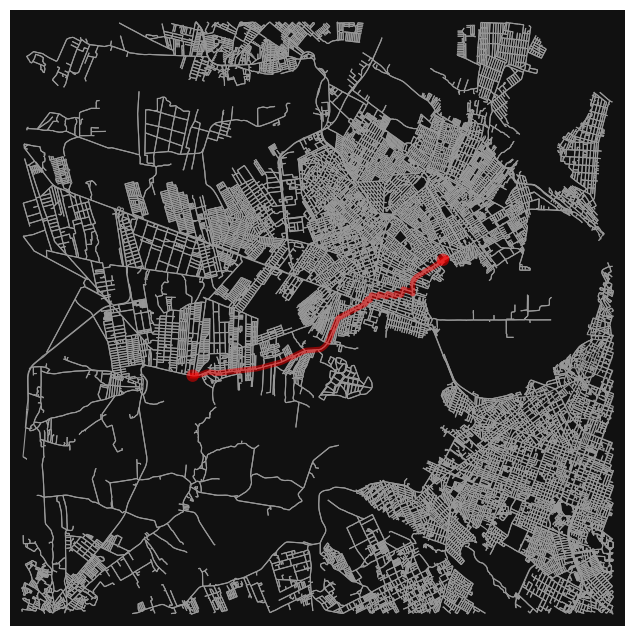

In [25]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()

#### **2.2 Análise:**
<font size=3>

Em uma **célula de markdown** descreva as principais características do algoritmo que você escolheu, respondendo:

- **Heurística:** Qual foi a função heurística `h(n)` que você utilizou para guiar a busca?

- **Função de Avaliação:** Como o seu algoritmo prioriza os nós na fronteira? Ele usa apenas a heurística $h(n)$, como a Busca Gananciosa, ou uma combinação de custo e heurística $f(n) = g(n) + h(n)$, como o A*?

- **Otimalidade:** A rota encontrada pelo seu algoritmo é **garantidamente** a de menor custo (menor distância total)? Explique como a sua escolha de heurística e função de avaliação afeta essa garantia.

  

### Busca pelo custo mínimo A* (A-Star Search)
* **Heurística** \
A função heurística utilizada foi a `haversine`.

* **Função de Avaliação** \
Esse algoritmo utiliza uma combinação de custo e heurística, especificado no trecho abaixo:

    ```py
    def search(self):

            (...)

            # A prioridade é f(n) = g(n) + h(n)
            # g(n) = root.path_cost (que é 0)
            # h(n) = self.h(root.state)

            priority = root.path_cost + self.h(root.state) 
    ```

* **Otimalidade** \
Segundo o [material](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D#scrollTo=328e359b-2d0f-430e-9e94-71186c445e62), a otimalidade da busca *A** depende de duas propriedades da heurística h(n). Nesse sentido, se h(n) for admissível (não ultrapassa o custo real ótimo) e consistente (não toma caminhos dos quais necessite "voltar", por não ter sido uma boa escolha), A* é completo e ótimo.

    Isso posto, como a `haversine` é uma função que nunca superestima o custo para alcançar seu objetivo, sendo admissível: [Heurística Admissível](https://www.opentrain.ai/glossary/admissible-heuristic/) e como também é consistente, especialmente por conseguir resolver o problema de arredondamento em distâncias curtas, pois usa funções de seno e cosseno para trazer uma maior [precisão](https://en.wikipedia.org/wiki/Haversine_formula) entre os pontos, então é **garantido** que a solução encontrada na busca A*, que usa a `haversine`, será a de menor custo.